<a href="https://colab.research.google.com/github/SaiOhmSaiePaine/food_not_food_text_classifier/blob/main/huggingface_text_classification_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning HuggingFace Text Classification

* Learning Source Site: ***Zero to Mastery***

* Tutorial: https://www.learnhuggingface.com/notebooks/hugging_face_text_classification_tutorial

* Setup: https://www.learnhuggingface.com/extras/setup

## Step on Creating Text Classification Model

1. Create and preprocess data.

2. Define the model we’d like use with `transformers.
AutoModelForSequenceClassification` (or another similar model class).

3. Define training arguments (these are hyperparameters for our model) with
`transformers.TrainingArguments`.

4. Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.

5. Train the model by calling `Trainer.train()`.

6. Save the model (to our local machine or to the Hugging Face Hub).

7. Evaluate the trained model by making and inspecting predctions on the test data.

8. Turn the model into a shareable demo.



## 2. Import necessary libraries



In [ ]:
try:
  import datasets, evaluate, accelerate
  import gradio as gr
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate
  import datasets, evaluate, accelerate
  import gradio as gr

import random

import numpy as np

import pandas as pd

import torch
import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using touch version: {torch.__version__}")
print(f"Using datasets version: {datasets.__version__}")

Using transformers version: 5.9.0
Using touch version: 2.11.0+cu128
Using datasets version: 5.0.0


## 3. Getting a dataset

Building food not food text classification model: need food not food text datasets.



In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset(path="mrdbourke/learn_hf_food_not_food_image_captions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [ ]:
dataset['train'][:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': ['food', 'not_food', 'not_food', 'not_food', 'not_food']}

In [ ]:
#What features are they?
dataset.column_names

{'train': ['text', 'label']}

In [ ]:
# Access the training split
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 250
})

### Inspect random samples

In [ ]:
import random

"""
random_indexs

random_samples
"""

random_indexs = random.sample(range(len(dataset['train'])), 5)
random_samples = dataset['train'][random_indexs]

print(random_indexs)

print("[INFO] Random samples from datasets:\n")
for text, label in zip(random_samples['text'], random_samples['label']):
  print(f"Text: {text} | Label: {label}")

[104, 175, 112, 49, 177]
[INFO] Random samples from datasets:

Text: A fruit platter with a variety of exotic fruits, such as dragon fruit, mangosteen, and durian | Label: food
Text: Set of pillows arranged on a couch | Label: not_food
Text: Rich and spicy lamb rogan josh with yogurt garnish, featuring tender lamb pieces in a bold sauce with spices, finished with creamy yogurt. | Label: food
Text: Pizza with a white sauce base, topped with spinach and artichokes | Label: food
Text: Green beans in a bowl, sprinkled with almonds and served with a side of lemon vinaigrette for a healthy, tasty dish. | Label: food


In [ ]:
# Get unique label values
dataset['train'].unique('label')

['food', 'not_food']

In [ ]:
# Check the count of each label
from collections import Counter

Counter(dataset['train']['label'])

Counter({'food': 125, 'not_food': 125})

In [ ]:
# Turn our dataset into a DataFrame and get a random sample

food_not_food_df = pd.DataFrame(dataset['train'])
random_samples = food_not_food_df.sample(7)
random_samples

,text,label
81,"Working from home at her desk, a woman deals w...",not_food
26,"Fresh cherry tomatoes in a basket, sprinkled w...",food
63,"Spicy vindaloo curry with tender pork pieces, ...",food
61,Basketball hoop set up in a driveway,not_food
44,"Pizza with a gluten-free crust, suitable for t...",food
196,Friends having a barbecue in the backyard whil...,not_food
116,A girl feeding her rabbit in the garden,not_food


## 4. Preparing data for text classification

 1. Tokenize text: turn text into numbers (this goes from labels as well).
 2. Create a train/test split: want to train the model on the training split and want to evaluate the model on the test split.

In [ ]:
# Count each label values | Check balance or imbalance dataset
food_not_food_df["label"].value_counts()

,count
label,
food,125
not_food,125


In [ ]:
# Create mapping programmatically from dataset
idx2label = {idx: label for idx, label in enumerate(dataset['train'].unique('label')[::-1])}
label2idx = {label: idx for idx, label in idx2label.items()}

In [ ]:
print(idx2label)
print(label2idx)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [ ]:
# Turn label to 0 and 1
def map_labels_to_numerical(example):
  example['label'] = label2idx[example['label']]

  return example

example = {'text': 'I like to eat chicken rice', 'label': 'food'}

print(map_labels_to_numerical(example))

{'text': 'I like to eat chicken rice', 'label': 1}


In [ ]:
# Map the dataset labels to number (the whole datasets)
dataset = dataset['train'].map(map_labels_to_numerical)
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [ ]:
# Shuffle data and look at 5 random samples
dataset.shuffle()[:5]

{'text': ['Sushi platter featuring a rainbow of colors with salmon, tuna, and avocado.',
  'Pizza with a white sauce base, topped with spinach and artichokes',
  'Sleek silver laptop resting on a wooden desk',
  'Margherita pizza topped with fresh basil leaves and juicy tomatoes',
  'Set of mugs hanging on a hook'],
 'label': [1, 1, 0, 1, 0]}

### Split the dataset into training and test sets

* Train set = model will learn the patterns on this dataset
* Validation set(optional) = we can tune model's hyperparameters on this set
* Test set = model will evaluate the patterns on this dataset

In [ ]:
# Split the data into train/test set
dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [ ]:
# Examine the training random sample
random_idx_train = random.randint(0, len(dataset['train']))
random_sample_train = dataset['train'][random_idx_train]
random_sample_train

{'text': 'Sushi with unique toppings like seared tuna or eel sauce.',
 'label': 1}

In [ ]:
# Examine the test random sample
random_idx_test = random.randint(0, len(dataset['test']))
random_sample_test = dataset['test'][random_idx_test]
random_sample_test

{'text': 'Artichokes in a bowl, sprinkled with garlic and served with a side of lemon aioli for a tasty, sophisticated dish.',
 'label': 1}

### Tokenize the texts (turning texts into number)

The premise of tokenizaion is to turn words into number.

E.g. "I love you" --> [20, 58, 74]


--

* The transformers library has in-build support for Hugging Face tokenizers.

* And the class transformers.AutoTokenizer helps pair the model to the tokeinzers.

--

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path='distilbert/distilbert-base-uncased', use_fast=True)
# Use the fast implementation (on by default, note: it requires Rust installed to run in local)

tokenizer


BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [ ]:
# Test out the tokenizer
# OpenAI = [40, 3021, 16585, 0]
tokenizer('I love pussy!')

{'input_ids': [101, 1045, 2293, 22418, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}

* input_ids = text turned into numbers
* attention_mask = whether or not to pay attention to certain tokens (1 = yes pay attention, 0 = no do not pay attention)

In [ ]:
# Get the length of the tokenizer vocab

length_tokenizer_vocab = len(tokenizer.vocab)

# Get the maximum sequence length the tokenizer can handle
max_sequence_length = tokenizer.model_max_length

print(f"[INFO] Number of items in tokenizoer vocab : {length_tokenizer_vocab}")
print(f"[INFO] Max tokenizer input sequence length: {max_sequence_length}")

[INFO] Number of items in tokenizoer vocab : 30522
[INFO] Max tokenizer input sequence length: 512


In [ ]:
# Tokenize a word
tokenizer('paine')

{'input_ids': [101, 3255, 2063, 102], 'token_type_ids': [0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1]}

In [ ]:
# Check if the vocab is in the tokenizer vocab
tokenizer.vocab['pizza']

10733

In [ ]:
# See how the word get tokenized
tokenizer.convert_ids_to_tokens(tokenizer("paine").input_ids)

['[CLS]', 'pain', '##e', '[SEP]']

In [ ]:
# Try to tokenize an emoji
tokenizer.convert_ids_to_tokens(tokenizer("❤️").input_ids)

['[CLS]', '[UNK]', '[SEP]']

In [ ]:
# Get the first three items in the tokenizer vocab
sorted(tokenizer.vocab.items())[:3]

[('!', 999), ('"', 1000), ('#', 1001)]

In [ ]:
# Get five random items in tokenizer vocab

random.sample(sorted(tokenizer.vocab.items()), k=5)

[('##bio', 26282),
 ('chilean', 12091),
 ('ignored', 6439),
 ('timely', 23259),
 ('lyndon', 23037)]

### Making a preprocessing function to tokenize text

Want to make it easy to go from sample -> tokenized_sample.

In [ ]:
def tokenize_text(examples):
  """
  Tokenize given text and return tokenized text.
  """

  return tokenizer(examples["text"],
                   padding=True, # pad short sequences to longest sequence in the batch
                   truncation=True) # truncate long sequences to the maximum length the model can handle

In [ ]:
example_text2 = {'text': "I love playing video game.", "label": 1}

# Test function
tokenize_text(example_text2)

{'input_ids': [101, 1045, 2293, 2652, 2678, 2208, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
# Map tokenize text function into the dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                                batched=True, # set batched=True to operate across batches of examples rather than only single examples
                                batch_size=1000) # defaults to 1000, can be increased if you have a large dataset

tokenized_dataset

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50
    })
})

* Note: In machine learning, it is often faster to do things in batches rather than one at the time during leveraging computer hardware parallelization.

See more in the map documentation: https://huggingface.co/docs/datasets/en/process#batch-processing


In [ ]:
# Get two samples from the tokenized dataset
train_tokenized_sample = tokenized_dataset['train'][0]
test_tokenized_sample = tokenized_dataset['test'][0]

for key in train_tokenized_sample.keys():
  print(f" [INFO] Key: {key}")
  print(f" Train sample: {train_tokenized_sample[key]}")
  print(f" Test sample: {test_tokenized_sample[key]}")
  print()


 [INFO] Key: text
 Train sample: Set of headphones placed on a desk
 Test sample: A slice of pepperoni pizza with a layer of melted cheese

 [INFO] Key: label
 Train sample: 0
 Test sample: 1

 [INFO] Key: input_ids
 Train sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

 [INFO] Key: token_type_ids
 Train sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Test sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

 [INFO] Key: attention_mask
 Train sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1

### Tokenization Takeaways

1. Tokenizer = turn the data into numbers (e.g. text -> map to number)
2. Many Models are out there and have different tokenizers, Hugging Face's Auto (e.g. Autotokenizer, AutoProcessor, AutoModel, etc help to match tokenizers to models)
3. Tokenization can help in parallel using map and batched functions

## 5. Setting up an Evaluation Metrics

In [ ]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load('accuracy')

def compute_accuracy(predictions_and_labels: Tuple[np.array, np.array]):
  """
  Compute the accuracy of the model by comparing predictions and true labels
  """

  predictions, labels = predictions_and_labels

  # Get the highest prediction probability of each prediction if predictions are probabilities
  if len(predictions.shape) >= 2:
    predictions = np.argmax(predictions, axis=1)

  return accuracy_metric.compute(predictions=predictions, references=labels)

In [ ]:
# Create example list of predictions and labels
example_predictions_all_correct = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
example_predictions_one_wrong = np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])
example_labels_all_correct = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

print(f"Accuracy when all predictions are correct: {compute_accuracy((example_predictions_all_correct, example_labels_all_correct))}")
print(f"Accuracy when one prediction is wrong: {compute_accuracy((example_predictions_one_wrong, example_labels_all_correct))}")

Accuracy when all predictions are correct: {'accuracy': 1.0}
Accuracy when one prediction is wrong: {'accuracy': 0.9}


In [ ]:
# Get id and label mappings
print(f"label2id: {label2idx}")
print(f"id2label: {idx2label}")

label2id: {'not_food': 0, 'food': 1}
id2label: {0: 'not_food', 1: 'food'}


In [ ]:
from transformers import AutoModelForSequenceClassification

# Set up model for fine-tuning with classification head (top layers of network)
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "distilbert/distilbert-base-uncased",
    num_labels = 2, # (foot/ not_food) can customize this to the number of classes in our own dataset
    id2label = idx2label, # mappings from class ID to class labels (for classification tasks)
    label2id = label2idx

)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


The model is comprised of the following parts:

1. `embeddings` - embeddings are a form of learned representation of tokens. So if tokens are a direct mapping from token to number, embedding are a learning vector representation.
2. `transformer` - the model architecture backbone, this has discoverd patterns/relationships in the embeddings.
3. `classifier` - we need to customize this layer to suit our problem.

Note: If you get input errors from passing a sample to a model, make sure the sample you pass to your model is formatting in the same way you model was trained on. For example, if your model used a specific tokenizer, make sure to tokenize your text before passing it to the model.

`model([102, 80, 300, 98])` wil not work✅.

### Count the parameters in the model

Weights/parameters = small numeric opportunies for a model to learn patterns in data.

In [ ]:
def count_params(model):
  """
  Count the parameters of a Pytouch model.
  """
  trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
  total_parameters = sum(p.numel() for p in model.parameters())

  return {"trainable parameters:": trainable_parameters, "total parameters:": total_parameters}

# Counts the parameters of the model
count_params(model)

{'trainable parameters:': 66955010, 'total parameters:': 66955010}

The model that I am using has around **67M** parameters and **all** of them are trainable.

Note:
* Generally, the more parameters a model has, the more capacity it has to learn.
* For comparison models such as Llama 3 8B has 8 billion parameters.
* If you want the best possible performance, generally more parameters is better.
  * However, with more parameters requires more compute + time.
  * You'll be suprised how well a samller model can perform with specific data.



### Create a directory for saving models

In [ ]:
# Create model output directory
from pathlib import Path

# Create model directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Create model save name
model_save_name = 'learn_hf_food_not_food_text_classifier-distilbert-base-uncased'

# Create model save path
model_save_dir = Path(models_dir, model_save_name)

model_save_dir


PosixPath('models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased')

## Setting up training arguments with TrainingArguments

In [ ]:
from transformers import TrainingArguments

print(f"[INFO] Saving model checkpoints to: {model_save_dir}")

# Create training arguments
training_args = TrainingArguments(
    output_dir = model_save_dir,
    learning_rate = 0.0001,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy="epoch",
    report_to="none",
    # push_to_hub=True,
    # hub_token="own_token_here",
    hub_private_repo=False
)

[INFO] Saving model checkpoints to: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


In [ ]:
# training_args

## Setting up an instance of Trainer

In [ ]:
tokenizer

BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

#Set up trainer
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_dataset['train'],
    eval_dataset = tokenized_dataset['test'],
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics = compute_accuracy,
)

### Training the model

In [ ]:
# Train a text classification model
result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.426414,0.081787,1.000000
2,0.036145,0.008919,1.000000
3,0.005906,0.003000,1.000000
4,0.002287,0.001614,1.000000
5,0.001388,0.001101,1.000000
6,0.001030,0.000875,1.000000
7,0.000857,0.000756,1.000000
8,0.000758,0.000692,1.000000
9,0.000704,0.000659,1.000000
10,0.000661,0.000648,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Inspect training metrics
for key, value in result.metrics.items():
  print(f"{key}: {value}")

train_runtime: 109.1904
train_samples_per_second: 18.317
train_steps_per_second: 0.641
total_flos: 18110777160000.0
train_loss: 0.04761508683274899
epoch: 10.0


### Save the model for later use

**Note**: if you are saving a model to Google Colab, note that it will disappear from Colab instance when it disconnects.

In [ ]:
# Save model
print(f"[INFO] Saving model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

[INFO] Saving model to models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Inspect the model training metrics

In [ ]:
# Get training history
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1] # get everything except the training time metrics (we've seen these already)
trainer_history_training_time = trainer_history_all[:1] # this is the same value as results.metrics from above

# View the first 4 metrics from the training history
trainer_history_metrics[:4]

[{'loss': 0.4264141150883266,
  'grad_norm': 1.8376201391220093,
  'learning_rate': 9.142857142857143e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.08178737014532089,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.0571,
  'eval_samples_per_second': 875.755,
  'eval_steps_per_second': 35.03,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.03614489947046552,
  'grad_norm': 0.1956104338169098,
  'learning_rate': 8.142857142857143e-05,
  'epoch': 2.0,
  'step': 14},
 {'eval_loss': 0.008918949402868748,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.0537,
  'eval_samples_per_second': 930.707,
  'eval_steps_per_second': 37.228,
  'epoch': 2.0,
  'step': 14}]

In [ ]:
import pprint

# Extract training and evaluation metrics
trainer_history_eval_set = []
trainer_history_training_set = []

# Loop through metrics and filter for training and eval metrics
for item in trainer_history_metrics:
  item_keys = list(item.keys())

  # Check to see if "eval" is in the keys of the item
  if any("eval" in item for item in item_keys):
    trainer_history_eval_set.append(item)
  else:
    trainer_history_training_set.append(item)

# Show the first two items in each metric set
print("[INFO] First two items in training set:")
pprint.pprint(trainer_history_training_set[:2])

print("\n [INFO] First two items in evaluation set:")
pprint.pprint(trainer_history_eval_set[:2])

[INFO] First two items in training set:
[{'epoch': 1.0,
  'grad_norm': 1.8376201391220093,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.4264141150883266,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.1956104338169098,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.03614489947046552,
  'step': 14}]

 [INFO] First two items in evaluation set:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.08178737014532089,
  'eval_runtime': 0.0571,
  'eval_samples_per_second': 875.755,
  'eval_steps_per_second': 35.03,
  'step': 7},
 {'epoch': 2.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.008918949402868748,
  'eval_runtime': 0.0537,
  'eval_samples_per_second': 930.707,
  'eval_steps_per_second': 37.228,
  'step': 14}]


In [ ]:
# Create pandas DataFrames for the training and evaluation metrics
trainer_history_training_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

In [ ]:
trainer_history_training_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.426414,1.837620,0.000091,1.0,7
1,0.036145,0.195610,0.000081,2.0,14
2,0.005906,0.055554,0.000071,3.0,21
3,0.002287,0.028422,0.000061,4.0,28
4,0.001388,0.018595,0.000051,5.0,35


In [ ]:
trainer_history_eval_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.081787,1.0,0.0571,875.755,35.030,1.0,7
1,0.008919,1.0,0.0537,930.707,37.228,2.0,14
2,0.003000,1.0,0.0534,937.107,37.484,3.0,21
3,0.001614,1.0,0.0551,907.285,36.291,4.0,28
4,0.001101,1.0,0.0607,823.203,32.928,5.0,35


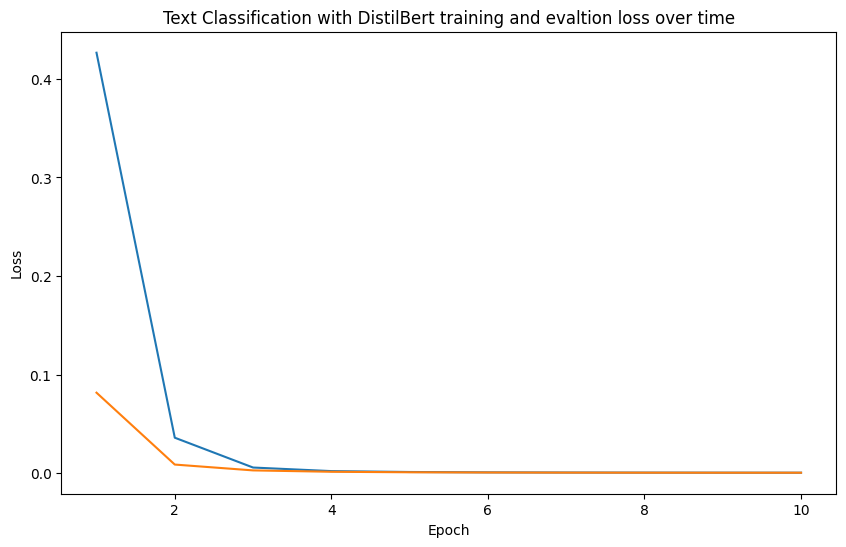

In [ ]:
# Plot training and evaluation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(trainer_history_training_df['epoch'], trainer_history_training_df['loss'], label='Training Loss')
plt.plot(trainer_history_eval_df['epoch'], trainer_history_eval_df['eval_loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Text Classification with DistilBert training and evaltion loss over time')

plt.show()

In [ ]:
# # Save Model to Hugging Face Hub
# # It will be public, since we set hub_private_repo=False in our TrainingArguments

# model_upload_url = trainer.push_to_hub(
#     commit_message = 'Uploading food not food text classification model',
#     # token="YOUR_HF_TOKEN_HERE" # This will default to the token you have saved in your Hugging Face config
# )

# print(f'[INFO] Model successfuly uploaded to Hugging Face Hub with at URL: {model_upload_url}')

## Making and evaluating predictions on the test dataset

In [ ]:
# Performs the predictions on the test set
predictions_all = trainer.predict(tokenized_dataset['test'])
predictions_values = predictions_all.predictions
predictions_metrics = predictions_all.metrics

print('[INFO] Predictions metrics on the test set.')
predictions_metrics

[INFO] Predictions metrics on the test set.


{'test_loss': 0.0006478402647189796,
 'test_accuracy': 1.0,
 'test_runtime': 0.0901,
 'test_samples_per_second': 555.183,
 'test_steps_per_second': 22.207}

### Get predicted probabilities and evaluate by hand

In [ ]:
import torch
from sklearn.metrics import accuracy_score

# Get predictons probability
pred_probs = torch.softmax(torch.tensor(predictions_values), dim=1)

# Get the predicted labels
pred_labels = torch.argmax(pred_probs, dim=1)

# Get the true labels from dataset
true_labels = tokenized_dataset['test']['label']

# Compare the true labels and prediction labels using accuracy_score
test_accuracy = accuracy_score(y_true=true_labels,
                               y_pred=pred_labels)

print(f"[INFO] Test Accuracy: {test_accuracy*100}%")

[INFO] Test Accuracy: 100.0%


**Note**: If you want a good evaluation method, make predictions on your entire test dataset, then index on the predictions which are wrong but have high prediction probability. For example, get the top 100-1000 and go through all of the examples where the model's prediction had high probability but was incorrect $\rightarrow$ this often leads to great insights into your data.

In [ ]:
idx2label

{0: 'not_food', 1: 'food'}

In [ ]:
label2idx

{'not_food': 0, 'food': 1}

In [ ]:
# Make a DataFrame of test predictions
test_predictions_df = pd.DataFrame({
    'text': dataset['test']['text'],
    'true_label': true_labels,
    'pred_label': pred_labels,
    'pred_prob': torch.max(pred_probs, dim=1).values,
})

test_predictions_df.head(5)

,text,true_label,pred_label,pred_prob
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.999338
1,Red brick fireplace with a mantel serving as a...,0,0,0.999554
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.999335
3,Set of mugs hanging on a hook,0,0,0.999587
4,Standing floor lamp providing light next to an...,0,0,0.999588


In [ ]:
# Show 10 examples with low predicton probability
test_predictions_df.sort_values('pred_prob', ascending=True).head(10)

,text,true_label,pred_label,pred_prob
43,Set of muffin tins stacked together,0,0,0.996523
40,A bowl of cherries with a sprig of mint for ga...,1,1,0.999299
13,"Comforting lamb curry bowl, featuring tender l...",1,1,0.999329
46,A bowl of sliced kiwi with a sprinkle of sugar...,1,1,0.999329
42,"Boxes of apples, pears, pineapple, manadrins a...",1,1,0.999330
31,Crunchy sushi roll with tempura flakes or pank...,1,1,0.999330
49,Plate of sushi served with pickled ginger and ...,1,1,0.999330
26,A fruit platter with a variety of exotic fruit...,1,1,0.999331
9,Cherry tomatoes and mozzarella balls in a bowl...,1,1,0.999331
11,A close-up shot of a cheesy pizza slice being ...,1,1,0.999331


## Making and inspecting predictions on custom text data

In [ ]:
# Set up the local model
local_model_path = 'models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased'

# Set up the Hugging Face model path
huggingface_model_path = 'SaiePaine/learn_hf_food_not_food_text_classifier-distilbert-base-uncased'

### Discussing ways to make predictions (inference)

**Note**: Whenever you hear the word "inference" it means to use a model to make predictions on data.

Two main ways to perform inference:
1. Pipeline mode - Using transformers. pipeline to load our model and perform text classification. See the docs:
https://huggingface.co/docs/transformers/en/main_classes/pipelines
2. PyTorch mode - Using a combination of transformers.AutoTokenizer and transformers.AutoModelForSequenceClassification
and passing each our target model name.

Each mode supports:
1. Predictions one at a time (fast but can be slower with many many samples).
    * Helpful for say a comment system and comments happen sporadically, to predict whether the comment was "spam" or "not spam".
2. Batches of prodictions at a time (faster but up to a point, e.g. say you predict on 32 samples at a time, this may be way faster than one at a time but if you go to 128 at a time, you may not see many more speedups).
    * Helpful for when you have a large static database or many samples coming in at once.

In [ ]:
# Setup our device for making predictions
# Note: generally the fast the hardware accelerator, the fast the predictions
# if you have a dedicated GPU, you should use over CPU.

def set_device():

  if torch.cuda.is_available():
    device = torch.device('cuda')
  elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
  else:
    device = torch.device('cpu')
  return device

DEVICE = set_device()
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


### Making predictions with pipeline

In [ ]:
import torch
from transformers import pipeline

# Set the batch size for predictions
BATCH_SIZE = 32

# Create an instance of transformers.pipeline
food_not_food_classifier = pipeline(
    task='text-classification',
    model=local_model_path,
    device=DEVICE,
    top_k=1,
    batch_size=BATCH_SIZE
)

food_not_food_classifier

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [ ]:
# Test the training model on example text
sample_text_food = "I eat bacon and egg."
food_not_food_classifier(sample_text_food)

[[{'label': 'food', 'score': 0.999272882938385}]]

In [ ]:
# Test the model on some more example text
sample_text_not_food = "A F1 car driving so fast in Monaco Grand Prix."
food_not_food_classifier(sample_text_not_food)

[[{'label': 'not_food', 'score': 0.9995065927505493}]]

In [ ]:
# Pass in random text to the model
food_not_food_classifier("cvnhertiejhwgdjshdfgh394587")

[[{'label': 'not_food', 'score': 0.9965196847915649}]]

In [ ]:
# Pipeline with remote models

food_not_food_classifier_remote = pipeline(
    task='text-classification',
    model=huggingface_model_path,
    batch_size=BATCH_SIZE,
    device=DEVICE,

)

food_not_food_classifier_remote


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [ ]:
food_not_food_classifier_remote('This is about bananas, pancake and ice cream.')

[{'label': 'food', 'score': 0.999359667301178}]

In [ ]:
# Testing with not food caption sentences
not_food_sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "We need to marinate these ideas overnight before presenting them to the client.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "A beautiful array of fake wax foods (shokuhin sampuru) in the front of a Japanese restaurant.",
    "Daniel Bourke is really cool :D",
    "A sleek stainless steel refrigerator standing empty in a modern kitchen showroom."
]

food_not_food_classifier_remote(not_food_sentences)

[{'label': 'not_food', 'score': 0.9989967942237854},
 {'label': 'not_food', 'score': 0.9993244409561157},
 {'label': 'not_food', 'score': 0.9993575215339661},
 {'label': 'not_food', 'score': 0.9993942975997925},
 {'label': 'not_food', 'score': 0.9992295503616333},
 {'label': 'not_food', 'score': 0.9993053674697876},
 {'label': 'not_food', 'score': 0.998995840549469},
 {'label': 'food', 'score': 0.9957600235939026},
 {'label': 'not_food', 'score': 0.9993940591812134},
 {'label': 'not_food', 'score': 0.9996089339256287}]

In [ ]:
# Testing with food caption sentences
food_sentences = [
    "My favourite food is biltong!",
    "I eat bacon and egg for breakfast almost every single morning.",
    "Sizzling hot pepperoni pizza with a thick layer of gooey, melted mozzarella cheese.",
    "A colorful bowl of mixed carrots, including vibrant orange and deep purple varieties.",
    "Creamy cauliflower curry served alongside warm, buttery garlic naan bread.",
    "A fresh fruit platter stacked with sliced mango, kiwi, strawberries, and pineapples.",
    "Two handfuls of ripe yellow bananas resting in a ceramic bowl on the dining table.",
    "Aromatic goat curry with tender meat pieces served over a bed of steamed basmati rice.",
    "Tangy fish curry bowl made with a zesty tamarind sauce and fresh curry leaves.",
    "A rich and spicy lamb rogan josh garnished with a dollop of creamy Greek yogurt."
]

food_not_food_classifier_remote(food_sentences)

[{'label': 'not_food', 'score': 0.992598295211792},
 {'label': 'food', 'score': 0.9981433153152466},
 {'label': 'food', 'score': 0.9993821382522583},
 {'label': 'food', 'score': 0.9993802309036255},
 {'label': 'food', 'score': 0.9993822574615479},
 {'label': 'food', 'score': 0.9993687272071838},
 {'label': 'food', 'score': 0.9992243051528931},
 {'label': 'food', 'score': 0.9993680119514465},
 {'label': 'food', 'score': 0.9993809461593628},
 {'label': 'food', 'score': 0.9993823766708374}]

In [ ]:
# Testing with confusing sentences
confusing_sentences = [
    # Uses explicit food names, but refers to tech/slang
    "He decided to flash the raspberry pi with a fresh Linux operating system.",
    "The security team discovered a serious data leak buried deep inside the apple ecosystem.",
    "Please don't use that sketchy website, it is completely filled with cookies and tracking scripts.",
    "She spent the afternoon squeezing juice out of her old iPhone battery to see if it would turn on.",

    # Uses heavy cooking metaphors for non-food activities
    "The corrupt politician was caught trying to cook the books before the tax audit.",
    "The defense attorney completely roasted the witness during the cross-examination.",
    "Let's just beef up our server infrastructure before the massive Black Friday traffic hits.",
    "He is a total couch potato who just stares at a monitor playing video games all day.",

    # Describes food items, but explicitly states they are inedible objects
    "A plastic replica of a pepperoni pizza sitting in a toy store window display.",
    "He bought a beautifully scented candle that smells exactly like fresh blueberry pancakes.",
    "She wore a bright yellow dress printed with tiny illustrations of avocados and lemons.",
    "The artist painted a stunning still life portrait featuring a bowl of grapes and a half-eaten loaf of bread."
]

food_not_food_classifier_remote(confusing_sentences)

[{'label': 'not_food', 'score': 0.9994606375694275},
 {'label': 'not_food', 'score': 0.9995225667953491},
 {'label': 'not_food', 'score': 0.9993017911911011},
 {'label': 'not_food', 'score': 0.9995506405830383},
 {'label': 'not_food', 'score': 0.9995680451393127},
 {'label': 'not_food', 'score': 0.9995254278182983},
 {'label': 'not_food', 'score': 0.9994499087333679},
 {'label': 'not_food', 'score': 0.9995743632316589},
 {'label': 'food', 'score': 0.5851497054100037},
 {'label': 'not_food', 'score': 0.994835376739502},
 {'label': 'food', 'score': 0.980263888835907},
 {'label': 'food', 'score': 0.9990752935409546}]

### Time the model across larger sample sizes

In [ ]:
import time

# Create 1000 sentences
sentences_1000 = food_sentences * 100

# Time how long it takes to make predictions on all sentences (one at a time)
print(f"[INFO] Number of sentences: {len(sentences_1000)}")

start_time_one_at_a_time = time.time()

for sentence in sentences_1000:
  # Make a prediction on each sentence one at a time
  food_not_food_classifier_remote(sentence)

end_time_one_at_a_time = time.time()

total_time_one_at_a_time = end_time_one_at_a_time - start_time_one_at_a_time

print(f"[INFO] Time taken for one at a time prediction: {total_time_one_at_a_time} seconds")
print(f"[INFO] Average inference time per sentence: {total_time_one_at_a_time / len(sentences_1000)} seconds")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[INFO] Number of sentences: 1000
[INFO] Time taken for one at a time prediction: 4.914283514022827 seconds
[INFO] Average inference time per sentence: 0.004914283514022827 seconds


In [ ]:
for i in [100, 1000, 10_000]:
  sentences_big = food_sentences * i
  print(f"[INFO] Number of sentences: {len(sentences_big)}")

  start_time = time.time()
  # Predict on all sentences in batches
  food_not_food_classifier_remote(sentences_big)

  end_time = time.time()

  print(f"[INFO] Time taken for a batch prediction of {len(sentences_big)} sentences: {end_time - start_time} seconds")
  print(f"[INFO] Average inference time per sentence: {(end_time - start_time) / len(sentences_big)} seconds")
  print()



[INFO] Number of sentences: 1000
[INFO] Time taken for a batch prediction of 1000 sentences: 2.4881200790405273 seconds
[INFO] Average inference time per sentence: 0.0024881200790405275 seconds

[INFO] Number of sentences: 10000
[INFO] Time taken for a batch prediction of 10000 sentences: 11.246199607849121 seconds
[INFO] Average inference time per sentence: 0.001124619960784912 seconds

[INFO] Number of sentences: 100000
[INFO] Time taken for a batch prediction of 100000 sentences: 89.92084527015686 seconds
[INFO] Average inference time per sentence: 0.0008992084527015686 seconds



### Making predictions with Pytoch

In [ ]:
from transformers import AutoTokenizer

# Setup Hugging Face model path
model_path = 'SaiePaine/learn_hf_food_not_food_text_classifier-distilbert-base-uncased'

# Create an example to predict on
sample_text_food = 'A delicious photo of a plate of scrambled eggs, bacon and toast'

# Prepare the tokenizer and tokenize the inputs
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_path)
inputs = tokenizer(sample_text_food,
                   return_tensors='pt') # return the output as PyTorch tensors

inputs

{'input_ids': tensor([[  101,  1037, 12090,  6302,  1997,  1037,  5127,  1997, 13501,  6763,
          1010, 11611,  1998, 15174,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
from transformers import AutoModelForSequenceClassification

# Load the Text Classificaton Model
model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_path)

model

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import torch

# It is a more modern, faster, and more secure drop-in replacement for the older with torch.no_grad(): context manager
# with torch.no_grad():
with torch.inference_mode():
  outputs = model(**inputs)
  outputs_verbo = model(input_ids=inputs['input_ids'],
                        attention_mask=inputs['attention_mask'])
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-3.4674,  3.7498]]), hidden_states=None, attentions=None)

In [ ]:
outputs_verbo

SequenceClassifierOutput(loss=None, logits=tensor([[-3.4674,  3.7498]]), hidden_states=None, attentions=None)

In [ ]:
# Convert logit to prediction probability + label

predicted_class_id = outputs.logits.argmax().item()
prediction_probability = torch.softmax(outputs.logits, dim=1).max().item()

print(f'Text: {sample_text_food}')
print(f'Predicted Label: {model.config.id2label[predicted_class_id]}')
print(f'Prediction probability: {prediction_probability}')

Text: A delicious photo of a plate of scrambled eggs, bacon and toast
Predicted Label: food
Prediction probability: 0.9992666840553284


In [ ]:
food_not_food_classifier_remote(sample_text_food)

[{'label': 'food', 'score': 0.9992666840553284}]